In [1]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import random
import copy
import time

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
from google.colab import files

uploaded = files.upload()

Saving nodes_dynamic.csv to nodes_dynamic.csv
Saving edges_dynamic.csv to edges_dynamic.csv


In [4]:
nodes = pd.read_csv("nodes_dynamic.csv")
edges = pd.read_csv("edges_dynamic.csv")

print("Nodes shape:", nodes.shape)
print("Edges shape:", edges.shape)

print("\nNode columns:")
print(nodes.columns.tolist())

print("\nEdge columns:")
print(edges.columns.tolist())

Nodes shape: (38250, 16)
Edges shape: (612971, 6)

Node columns:
['run', 'time', 'node_id', 'energy', 'trust', 'drop_rate', 'mobility', 'forward_ratio', 'delay', 'degree', 'packets_received', 'packets_forwarded', 'packets_dropped', 'route_hits', 'label', 'attack']

Edge columns:
['run', 'time', 'src', 'dst', 'edge_type', 'distance']


In [5]:
display(nodes.head())
display(edges.head())

,run,time,node_id,energy,trust,drop_rate,mobility,forward_ratio,delay,degree,packets_received,packets_forwarded,packets_dropped,route_hits,label,attack
0,1,0.0,0,0.908248,0.896262,0.009554,0.0,0.933121,18.936929,31.0,314,293,3,15,0,normal
1,1,0.0,1,0.846807,0.923623,0.037500,0.0,0.962500,20.636034,14.0,80,77,3,4,0,normal
2,1,0.0,2,0.955311,0.924596,0.008772,0.0,0.482456,18.675408,24.0,114,55,1,3,0,normal
3,1,0.0,3,0.872172,0.846788,0.028351,0.0,0.824742,16.541024,30.0,388,320,11,17,0,normal
4,1,0.0,4,0.975107,0.929081,0.075000,0.0,0.425000,22.515481,15.0,40,17,3,1,0,normal


,run,time,src,dst,edge_type,distance
0,1,0.0,0,17,radio,232.595046
1,1,0.0,0,26,radio,194.317127
2,1,0.0,0,30,radio,184.439955
3,1,0.0,0,31,radio,224.782738
4,1,0.0,0,33,radio,29.408747


In [6]:
print("Runs:", sorted(nodes["run"].unique()))

print("\nNumber of timestamps:")
print(nodes["time"].nunique())

print("\nFirst few timestamps:")
print(sorted(nodes["time"].unique())[:10])

print("\nLast few timestamps:")
print(sorted(nodes["time"].unique())[-10:])

print("\nLabel distribution:")
print(nodes["label"].value_counts())

print("\nAttack distribution:")
print(nodes["attack"].value_counts())

Runs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Number of timestamps:
51

First few timestamps:
[np.float64(0.0), np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(90.0)]

Last few timestamps:
[np.float64(410.0), np.float64(420.0), np.float64(430.0), np.float64(440.0), np.float64(450.0), np.float64(460.0), np.float64(470.0), np.float64(480.0), np.float64(490.0), np.float64(500.0)]

Label distribution:
label
0    35670
1     2580
Name: count, dtype: int64

Attack distribution:
attack
normal       35670
blackhole     1230
greyhole       930
wormhole       420
Name: count, dtype: int64


In [9]:
times = sorted(nodes["time"].unique())

split_index = int(len(times) * 0.70)

train_times = times[:split_index]
test_times = times[split_index:]

print("Total timestamps:", len(times))
print("Training timestamps:", len(train_times))
print("Testing timestamps:", len(test_times))

print("Train:", train_times[0], "to", train_times[-1])
print("Test:", test_times[0], "to", test_times[-1])

Total timestamps: 51
Training timestamps: 35
Testing timestamps: 16
Train: 0.0 to 340.0
Test: 350.0 to 500.0


In [10]:
train_nodes = nodes[nodes["time"].isin(train_times)].copy()
test_nodes = nodes[nodes["time"].isin(test_times)].copy()

print("TRAIN LABELS")
print(train_nodes["label"].value_counts())

print("\nTEST LABELS")
print(test_nodes["label"].value_counts())

print("\nTEST ATTACKS")
print(test_nodes["attack"].value_counts())

TRAIN LABELS
label
0    24950
1     1300
Name: count, dtype: int64

TEST LABELS
label
0    10720
1     1280
Name: count, dtype: int64

TEST ATTACKS
attack
normal       10720
blackhole      480
greyhole       480
wormhole       320
Name: count, dtype: int64


In [11]:
times = sorted(nodes["time"].unique())

split_index = int(len(times) * 0.70)

train_times = times[:split_index]
test_times = times[split_index:]

print("Total timestamps:", len(times))
print("Training timestamps:", len(train_times))
print("Testing timestamps:", len(test_times))

print("\nTraining period:")
print(train_times[0], "to", train_times[-1])

print("\nTesting period:")
print(test_times[0], "to", test_times[-1])

Total timestamps: 51
Training timestamps: 35
Testing timestamps: 16

Training period:
0.0 to 340.0

Testing period:
350.0 to 500.0


In [12]:
train_nodes = nodes[nodes["time"].isin(train_times)].copy()
test_nodes = nodes[nodes["time"].isin(test_times)].copy()

print("TRAIN LABEL DISTRIBUTION")
print(train_nodes["label"].value_counts())

print("\nTEST LABEL DISTRIBUTION")
print(test_nodes["label"].value_counts())

print("\nTEST ATTACK DISTRIBUTION")
print(test_nodes["attack"].value_counts())

TRAIN LABEL DISTRIBUTION
label
0    24950
1     1300
Name: count, dtype: int64

TEST LABEL DISTRIBUTION
label
0    10720
1     1280
Name: count, dtype: int64

TEST ATTACK DISTRIBUTION
attack
normal       10720
blackhole      480
greyhole       480
wormhole       320
Name: count, dtype: int64


In [13]:
features = [
    "energy",
    "trust",
    "drop_rate",
    "forward_ratio"
]

print("Features used:")
for feature in features:
    print(feature)

Features used:
energy
trust
drop_rate
forward_ratio


In [14]:
scaler = StandardScaler()

scaler.fit(train_nodes[features])

nodes_scaled = nodes.copy()

nodes_scaled[features] = scaler.transform(
    nodes[features]
)

print(nodes_scaled[features].head())

     energy     trust  drop_rate  forward_ratio
0  0.496797 -0.644365  -0.193714       0.834355
1 -0.530619 -0.358285   0.037300       0.916353
2  1.283801 -0.348115  -0.200181      -0.423485
3 -0.106466 -1.161651  -0.038334       0.531861
4  1.614837 -0.301214   0.347294      -0.583849


In [15]:
def create_graph(run_number, timestamp):

    node_part = nodes_scaled[
        (nodes_scaled["run"] == run_number) &
        (nodes_scaled["time"] == timestamp)
    ].copy()

    edge_part = edges[
        (edges["run"] == run_number) &
        (edges["time"] == timestamp)
    ].copy()

    node_part = node_part.sort_values("node_id")

    node_ids = node_part["node_id"].tolist()

    id_map = {
        node_id: i
        for i, node_id in enumerate(node_ids)
    }

    x = torch.tensor(
        node_part[features].values,
        dtype=torch.float
    )

    y = torch.tensor(
        node_part["label"].values,
        dtype=torch.long
    )

    edge_pairs = []

    for _, row in edge_part.iterrows():

        src = int(row["src"])
        dst = int(row["dst"])

        if src in id_map and dst in id_map:

            edge_pairs.append([
                id_map[src],
                id_map[dst]
            ])

            edge_pairs.append([
                id_map[dst],
                id_map[src]
            ])

    if len(edge_pairs) == 0:

        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )

    else:

        edge_index = torch.tensor(
            edge_pairs,
            dtype=torch.long
        ).t().contiguous()

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    graph.run = run_number
    graph.time = timestamp

    return graph

In [16]:
sample_graph = create_graph(1, 0.0)

print(sample_graph)

print("\nNumber of nodes:")
print(sample_graph.num_nodes)

print("\nNumber of edges:")
print(sample_graph.num_edges)

print("\nFeature shape:")
print(sample_graph.x.shape)

print("\nLabels:")
print(torch.bincount(sample_graph.y))

Data(x=[150, 4], edge_index=[2, 3632], y=[150], run=1, time=0.0)

Number of nodes:
150

Number of edges:
3632

Feature shape:
torch.Size([150, 4])

Labels:
tensor([150])


In [17]:
all_graphs = []

for run_number in sorted(nodes["run"].unique()):

    for timestamp in sorted(nodes["time"].unique()):

        graph = create_graph(
            run_number,
            timestamp
        )

        all_graphs.append(graph)

print("Total graphs created:", len(all_graphs))

Total graphs created: 255


In [18]:
train_graphs = [
    g for g in all_graphs
    if g.time in train_times
]

test_graphs = [
    g for g in all_graphs
    if g.time in test_times
]

print("Training graphs:", len(train_graphs))
print("Testing graphs:", len(test_graphs))

Training graphs: 175
Testing graphs: 80


In [19]:
class LightweightGCN(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(
            4,
            16
        )

        self.conv2 = GCNConv(
            16,
            2
        )

    def forward(self, x, edge_index):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        return x

In [20]:
model = LightweightGCN()

parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

print("Total trainable parameters:", parameter_count)

Total trainable parameters: 114


In [45]:
def train_client(model, client_graphs, malicious_weight, epochs=5):

    model.train()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    weights = torch.tensor(
        [1.0, malicious_weight],
        dtype=torch.float
    )

    loss_function = torch.nn.CrossEntropyLoss(
        weight=weights
    )

    for epoch in range(epochs):

        for graph in client_graphs:

            optimizer.zero_grad()

            output = model(
                graph.x,
                graph.edge_index
            )

            loss = loss_function(
                output,
                graph.y
            )

            loss.backward()
            optimizer.step()

    return copy.deepcopy(model.state_dict())

In [22]:
def federated_average(client_weights):

    average_weights = copy.deepcopy(
        client_weights[0]
    )

    for key in average_weights.keys():

        average_weights[key] = torch.stack(
            [
                weights[key].float()
                for weights in client_weights
            ]
        ).mean(dim=0)

    return average_weights

In [23]:
clients = {}

for run_number in sorted(nodes["run"].unique()):

    clients[run_number] = [
        graph
        for graph in train_graphs
        if graph.run == run_number
    ]

for client_id, graphs in clients.items():

    print(
        "Client",
        client_id,
        "-",
        len(graphs),
        "training snapshots"
    )

Client 1 - 35 training snapshots
Client 2 - 35 training snapshots
Client 3 - 35 training snapshots
Client 4 - 35 training snapshots
Client 5 - 35 training snapshots


In [36]:
global_model = LightweightGCN()

federated_rounds = 5

for round_number in range(federated_rounds):

    client_weights = []

    for client_id in clients:

        local_model = LightweightGCN()

        local_model.load_state_dict(
            global_model.state_dict()
        )

        weights = train_client(
            local_model,
            clients[client_id],
            epochs=10
        )

        client_weights.append(weights)

    new_global_weights = federated_average(
        client_weights
    )

    global_model.load_state_dict(
        new_global_weights
    )

    print(
        f"Federated Round {round_number + 1}/{federated_rounds} completed"
    )

Federated Round 1/5 completed
Federated Round 2/5 completed
Federated Round 3/5 completed
Federated Round 4/5 completed
Federated Round 5/5 completed


In [37]:
global_model.eval()

all_true = []
all_pred = []

with torch.no_grad():

    for graph in test_graphs:

        output = global_model(
            graph.x,
            graph.edge_index
        )

        prediction = output.argmax(
            dim=1
        )

        all_true.extend(
            graph.y.cpu().numpy()
        )

        all_pred.extend(
            prediction.cpu().numpy()
        )

all_true = np.array(all_true)
all_pred = np.array(all_pred)

In [38]:
accuracy = accuracy_score(
    all_true,
    all_pred
)

precision = precision_score(
    all_true,
    all_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    all_true,
    all_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    all_true,
    all_pred,
    pos_label=1,
    zero_division=0
)

print("FL-GCN RESULTS")
print("----------------------")

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Malicious Precision:",
    round(precision, 4)
)

print(
    "Malicious Recall:",
    round(recall, 4)
)

print(
    "Malicious F1:",
    round(f1, 4)
)

FL-GCN RESULTS
----------------------
Accuracy: 0.2136
Malicious Precision: 0.1165
Malicious Recall: 0.968
Malicious F1: 0.208


In [39]:
cm = confusion_matrix(
    all_true,
    all_pred,
    labels=[0, 1]
)

print(cm)

[[1324 9396]
 [  41 1239]]


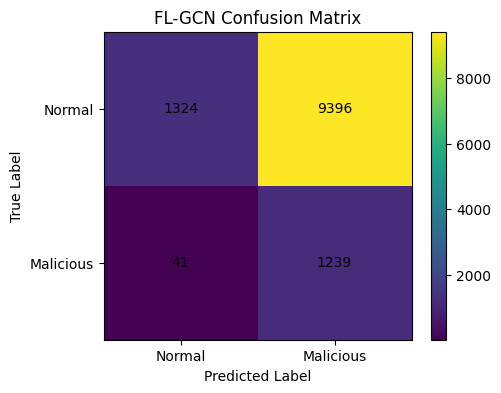

In [40]:
plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("FL-GCN Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Normal", "Malicious"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Malicious"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [41]:
print(
    classification_report(
        all_true,
        all_pred,
        target_names=[
            "Normal",
            "Malicious"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.97      0.12      0.22     10720
   Malicious       0.12      0.97      0.21      1280

    accuracy                           0.21     12000
   macro avg       0.54      0.55      0.21     12000
weighted avg       0.88      0.21      0.22     12000



In [42]:
normal_count = (train_nodes["label"] == 0).sum()
malicious_count = (train_nodes["label"] == 1).sum()

malicious_weight = normal_count / malicious_count

class_weights = torch.tensor(
    [1.0, malicious_weight],
    dtype=torch.float
)

print("Normal samples:", normal_count)
print("Malicious samples:", malicious_count)
print("Class weights:", class_weights)

Normal samples: 24950
Malicious samples: 1300
Class weights: tensor([ 1.0000, 19.1923])


In [43]:
normal_count = (train_nodes["label"] == 0).sum()
malicious_count = (train_nodes["label"] == 1).sum()

malicious_weight = normal_count / malicious_count

class_weights = torch.tensor(
    [1.0, malicious_weight],
    dtype=torch.float
)

print("Normal samples:", normal_count)
print("Malicious samples:", malicious_count)
print("Class weights:", class_weights)

Normal samples: 24950
Malicious samples: 1300
Class weights: tensor([ 1.0000, 19.1923])


In [44]:
train_times_list = sorted(train_times)

val_split = int(len(train_times_list) * 0.80)

fl_train_times = train_times_list[:val_split]
val_times = train_times_list[val_split:]

fl_train_graphs = [
    g for g in all_graphs
    if g.time in fl_train_times
]

val_graphs = [
    g for g in all_graphs
    if g.time in val_times
]

print("FL Training period:", fl_train_times[0], "to", fl_train_times[-1])
print("Validation period:", val_times[0], "to", val_times[-1])

print("Training graphs:", len(fl_train_graphs))
print("Validation graphs:", len(val_graphs))

FL Training period: 0.0 to 270.0
Validation period: 280.0 to 340.0
Training graphs: 140
Validation graphs: 35


In [46]:
def evaluate_graphs(model, graphs):

    model.eval()

    true_labels = []
    predictions = []

    with torch.no_grad():

        for graph in graphs:

            output = model(
                graph.x,
                graph.edge_index
            )

            pred = output.argmax(dim=1)

            true_labels.extend(
                graph.y.cpu().numpy()
            )

            predictions.extend(
                pred.cpu().numpy()
            )

    acc = accuracy_score(
        true_labels,
        predictions
    )

    precision = precision_score(
        true_labels,
        predictions,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        true_labels,
        predictions,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        predictions,
        pos_label=1,
        zero_division=0
    )

    return acc, precision, recall, f1

In [48]:
train_times_list = sorted(train_times)

val_split = int(len(train_times_list) * 0.80)

fl_train_times = train_times_list[:val_split]
val_times = train_times_list[val_split:]

fl_train_graphs = [
    g for g in all_graphs
    if g.time in fl_train_times
]

val_graphs = [
    g for g in all_graphs
    if g.time in val_times
]

print("FL Training period:", fl_train_times[0], "to", fl_train_times[-1])
print("Validation period:", val_times[0], "to", val_times[-1])

print("Training graphs:", len(fl_train_graphs))
print("Validation graphs:", len(val_graphs))

FL Training period: 0.0 to 270.0
Validation period: 280.0 to 340.0
Training graphs: 140
Validation graphs: 35


In [49]:
fl_clients = {}

for run_number in sorted(nodes["run"].unique()):

    fl_clients[run_number] = [
        graph
        for graph in fl_train_graphs
        if graph.run == run_number
    ]

for client_id, graphs in fl_clients.items():
    print("Client", client_id, ":", len(graphs), "graphs")

Client 1 : 28 graphs
Client 2 : 28 graphs
Client 3 : 28 graphs
Client 4 : 28 graphs
Client 5 : 28 graphs


In [50]:
weights_to_try = [2.0, 4.0, 6.0, 8.0]

weight_results = []

for weight_value in weights_to_try:

    print("\nTesting weight:", weight_value)

    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    model_test = LightweightGCN()

    for round_number in range(5):

        client_weights = []

        for client_id in fl_clients:

            local_model = LightweightGCN()

            local_model.load_state_dict(
                model_test.state_dict()
            )

            w = train_client(
                local_model,
                fl_clients[client_id],
                malicious_weight=weight_value,
                epochs=5
            )

            client_weights.append(w)

        avg = federated_average(
            client_weights
        )

        model_test.load_state_dict(avg)

    acc, precision, recall, f1 = evaluate_graphs(
        model_test,
        val_graphs
    )

    weight_results.append([
        weight_value,
        acc,
        precision,
        recall,
        f1
    ])

    print("Accuracy:", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1:", round(f1, 4))


Testing weight: 2.0
Accuracy: 0.8989
Precision: 0.359
Recall: 0.0269
F1: 0.0501

Testing weight: 4.0
Accuracy: 0.8931
Precision: 0.3459
Recall: 0.0885
F1: 0.1409

Testing weight: 6.0
Accuracy: 0.8486
Precision: 0.2244
Recall: 0.2154
F1: 0.2198

Testing weight: 8.0
Accuracy: 0.771
Precision: 0.1917
Recall: 0.4077
F1: 0.2608


In [51]:
weight_table = pd.DataFrame(
    weight_results,
    columns=[
        "Weight",
        "Accuracy",
        "Malicious Precision",
        "Malicious Recall",
        "Malicious F1"
    ]
)

display(weight_table)

,Weight,Accuracy,Malicious Precision,Malicious Recall,Malicious F1
0,2.0,0.898857,0.358974,0.026923,0.050089
1,4.0,0.893143,0.345865,0.088462,0.140888
2,6.0,0.848571,0.224449,0.215385,0.219823
3,8.0,0.771048,0.191682,0.407692,0.260763


In [52]:
final_clients = {}

for run_number in sorted(nodes["run"].unique()):

    final_clients[run_number] = [
        graph
        for graph in train_graphs
        if graph.run == run_number
    ]

for client_id, graphs in final_clients.items():
    print("Client", client_id, ":", len(graphs), "graphs")

Client 1 : 35 graphs
Client 2 : 35 graphs
Client 3 : 35 graphs
Client 4 : 35 graphs
Client 5 : 35 graphs


In [53]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

global_model = LightweightGCN()

final_weight = 8.0
federated_rounds = 5

for round_number in range(federated_rounds):

    client_weights = []

    for client_id in final_clients:

        local_model = LightweightGCN()

        local_model.load_state_dict(
            global_model.state_dict()
        )

        w = train_client(
            local_model,
            final_clients[client_id],
            malicious_weight=final_weight,
            epochs=5
        )

        client_weights.append(w)

    avg_weights = federated_average(client_weights)

    global_model.load_state_dict(avg_weights)

    print(
        f"Round {round_number + 1}/{federated_rounds} completed"
    )

Round 1/5 completed
Round 2/5 completed
Round 3/5 completed
Round 4/5 completed
Round 5/5 completed


In [54]:
global_model.eval()

all_true = []
all_pred = []

with torch.no_grad():

    for graph in test_graphs:

        output = global_model(
            graph.x,
            graph.edge_index
        )

        pred = output.argmax(dim=1)

        all_true.extend(
            graph.y.cpu().numpy()
        )

        all_pred.extend(
            pred.cpu().numpy()
        )

all_true = np.array(all_true)
all_pred = np.array(all_pred)

In [55]:
accuracy = accuracy_score(all_true, all_pred)

precision = precision_score(
    all_true,
    all_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    all_true,
    all_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    all_true,
    all_pred,
    pos_label=1,
    zero_division=0
)

print("FINAL FL-GCN RESULTS")
print("--------------------")
print("Accuracy:", round(accuracy, 4))
print("Malicious Precision:", round(precision, 4))
print("Malicious Recall:", round(recall, 4))
print("Malicious F1:", round(f1, 4))

FINAL FL-GCN RESULTS
--------------------
Accuracy: 0.7319
Malicious Precision: 0.1982
Malicious Recall: 0.4969
Malicious F1: 0.2834


In [56]:
def run_fl_experiment(seed):

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = LightweightGCN()

    for round_number in range(5):

        client_weights = []

        for client_id in final_clients:

            local_model = LightweightGCN()

            local_model.load_state_dict(
                model.state_dict()
            )

            w = train_client(
                local_model,
                final_clients[client_id],
                malicious_weight=8.0,
                epochs=5
            )

            client_weights.append(w)

        avg_weights = federated_average(
            client_weights
        )

        model.load_state_dict(
            avg_weights
        )

    model.eval()

    true_labels = []
    predictions = []

    with torch.no_grad():

        for graph in test_graphs:

            output = model(
                graph.x,
                graph.edge_index
            )

            pred = output.argmax(dim=1)

            true_labels.extend(
                graph.y.cpu().numpy()
            )

            predictions.extend(
                pred.cpu().numpy()
            )

    acc = accuracy_score(
        true_labels,
        predictions
    )

    precision = precision_score(
        true_labels,
        predictions,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        true_labels,
        predictions,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        predictions,
        pos_label=1,
        zero_division=0
    )

    return acc, precision, recall, f1

In [57]:
seeds = [10, 20, 30, 40, 50]

results = []

for seed in seeds:

    print("Running seed:", seed)

    acc, precision, recall, f1 = run_fl_experiment(
        seed
    )

    results.append([
        seed,
        acc,
        precision,
        recall,
        f1
    ])

    print(
        "Accuracy:",
        round(acc, 4),
        "| Recall:",
        round(recall, 4),
        "| F1:",
        round(f1, 4)
    )

Running seed: 10
Accuracy: 0.6594 | Recall: 0.6039 | F1: 0.2745
Running seed: 20
Accuracy: 0.6853 | Recall: 0.5594 | F1: 0.275
Running seed: 30
Accuracy: 0.7283 | Recall: 0.5 | F1: 0.2819
Running seed: 40
Accuracy: 0.7422 | Recall: 0.4688 | F1: 0.2795
Running seed: 50
Accuracy: 0.7026 | Recall: 0.5359 | F1: 0.2777


In [58]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Seed",
        "Accuracy",
        "Malicious Precision",
        "Malicious Recall",
        "Malicious F1"
    ]
)

display(results_df)

,Seed,Accuracy,Malicious Precision,Malicious Recall,Malicious F1
0,10,0.659417,0.177579,0.603906,0.274454
1,20,0.685333,0.182281,0.559375,0.274962
2,30,0.728333,0.196319,0.500000,0.281938
3,40,0.742167,0.199071,0.468750,0.279460
4,50,0.702583,0.187380,0.535937,0.277677


In [59]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Malicious Precision",
        "Malicious Recall",
        "Malicious F1"
    ],

    "Mean": [
        results_df["Accuracy"].mean(),
        results_df["Malicious Precision"].mean(),
        results_df["Malicious Recall"].mean(),
        results_df["Malicious F1"].mean()
    ],

    "Std": [
        results_df["Accuracy"].std(),
        results_df["Malicious Precision"].std(),
        results_df["Malicious Recall"].std(),
        results_df["Malicious F1"].std()
    ]
})

display(summary)

,Metric,Mean,Std
0,Accuracy,0.703567,0.033113
1,Malicious Precision,0.188526,0.009112
2,Malicious Recall,0.533594,0.052315
3,Malicious F1,0.277698,0.003126


In [60]:
results_df.to_csv(
    "fl_gcn_5runs.csv",
    index=False
)

summary.to_csv(
    "fl_gcn_summary.csv",
    index=False
)

print("Results saved")

Results saved


In [61]:
from google.colab import files

files.download("fl_gcn_5runs.csv")
files.download("fl_gcn_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>